## 📊 Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path to import helpers
sys.path.append('src')
from src.helpers import load_dataset, filter_data, add_columns, summarize_by_group, get_top_n, plot

# Load the Spotify dataset
spotify = load_dataset('spotify')

print(f"Dataset shape: {spotify.shape}")
print(f"\nColumns: {list(spotify.columns)}")
spotify.head()

Dataset shape: (18679, 21)

Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 🔍 Initial Data Exploration

In [2]:
# Basic dataset information
print("Dataset Info:")
print(spotify.info())
print("\n" + "="*50)
print("\nMissing values:")
print(spotify.isnull().sum())
print("\n" + "="*50)
print("\nBasic statistics:")
spotify.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18679 entries, 0 to 18678
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        18679 non-null  int64  
 1   track_id          18679 non-null  object 
 2   artists           18679 non-null  object 
 3   album_name        18679 non-null  object 
 4   track_name        18679 non-null  object 
 5   popularity        18679 non-null  int64  
 6   duration_ms       18679 non-null  int64  
 7   explicit          18679 non-null  bool   
 8   danceability      18679 non-null  float64
 9   energy            18679 non-null  float64
 10  key               18679 non-null  int64  
 11  loudness          18679 non-null  float64
 12  mode              18679 non-null  int64  
 13  speechiness       18679 non-null  float64
 14  acousticness      18679 non-null  float64
 15  instrumentalness  18679 non-null  float64
 16  liveness          18679 no

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,18679.000000,18679.000000,1.867900e+04,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000,18679.000000
mean,50688.541678,60.377857,2.203659e+05,0.578745,0.619917,5.296590,-8.320470,0.617217,0.077695,0.314259,0.127359,0.186305,0.453108,121.245293,3.918572
std,32952.329748,8.154235,7.768108e+04,0.167322,0.247800,3.562837,5.597746,0.486079,0.079810,0.322889,0.283602,0.153905,0.244667,29.469173,0.390564
min,0.000000,50.000000,3.062200e+04,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000000,0.000000,0.000000,0.011400,0.000000,0.000000,0.000000
25%,22071.000000,54.000000,1.741735e+05,0.472000,0.459000,2.000000,-9.694000,0.000000,0.035100,0.024500,0.000000,0.097000,0.253000,98.513000,4.000000
50%,47755.000000,59.000000,2.102990e+05,0.590000,0.658000,5.000000,-6.879000,1.000000,0.046900,0.184000,0.000024,0.123000,0.435000,120.966000,4.000000
75%,80104.500000,65.000000,2.537215e+05,0.702000,0.822000,8.000000,-4.968500,1.000000,0.080550,0.572000,0.013700,0.227000,0.642000,139.965000,4.000000
max,113959.000000,100.000000,3.340672e+06,0.980000,0.999000,11.000000,1.023000,1.000000,0.914000,0.996000,1.000000,0.991000,0.992000,243.372000,5.000000


Number of unique genres: 107

Genre distribution:
track_genre
pop-film      740
chill         699
k-pop         583
hip-hop       508
deep-house    500
ambient       495
anime         479
british       475
emo           440
grunge        424
Name: count, dtype: int64


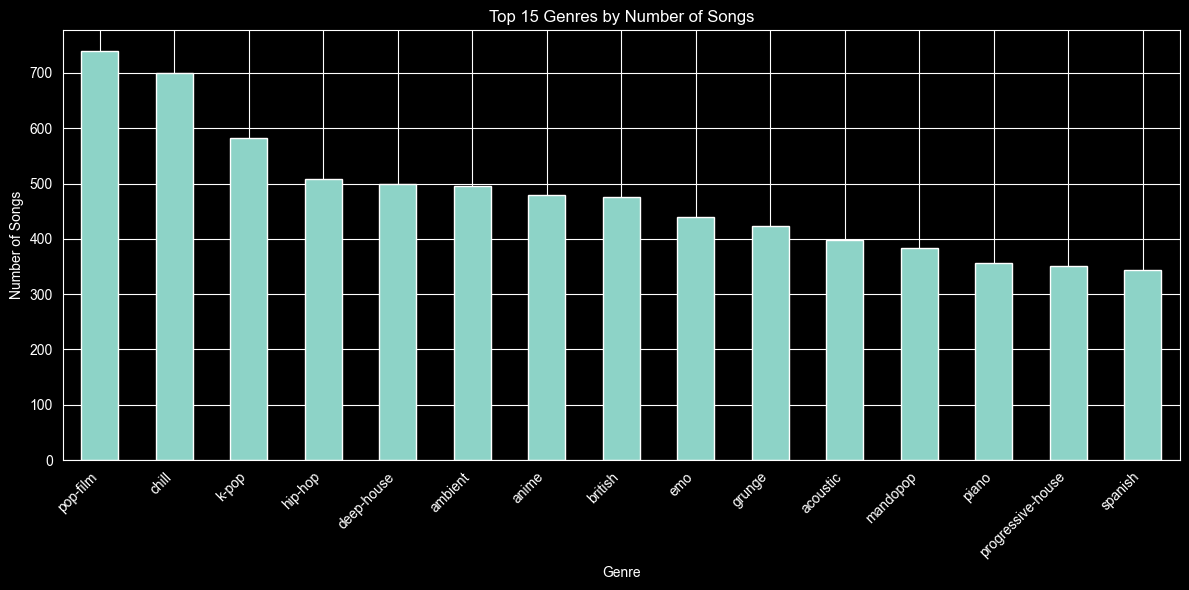

In [3]:
# Explore genres
print(f"Number of unique genres: {spotify['track_genre'].nunique()}")
print("\nGenre distribution:")
genre_counts = spotify['track_genre'].value_counts()
print(genre_counts.head(10))

# Visualize genre distribution
plt.figure(figsize=(12, 6))
genre_counts.head(15).plot(kind='bar')
plt.title('Top 15 Genres by Number of Songs')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 📈 Audio Feature Distributions

Let's examine how the key audio features are distributed across all songs.

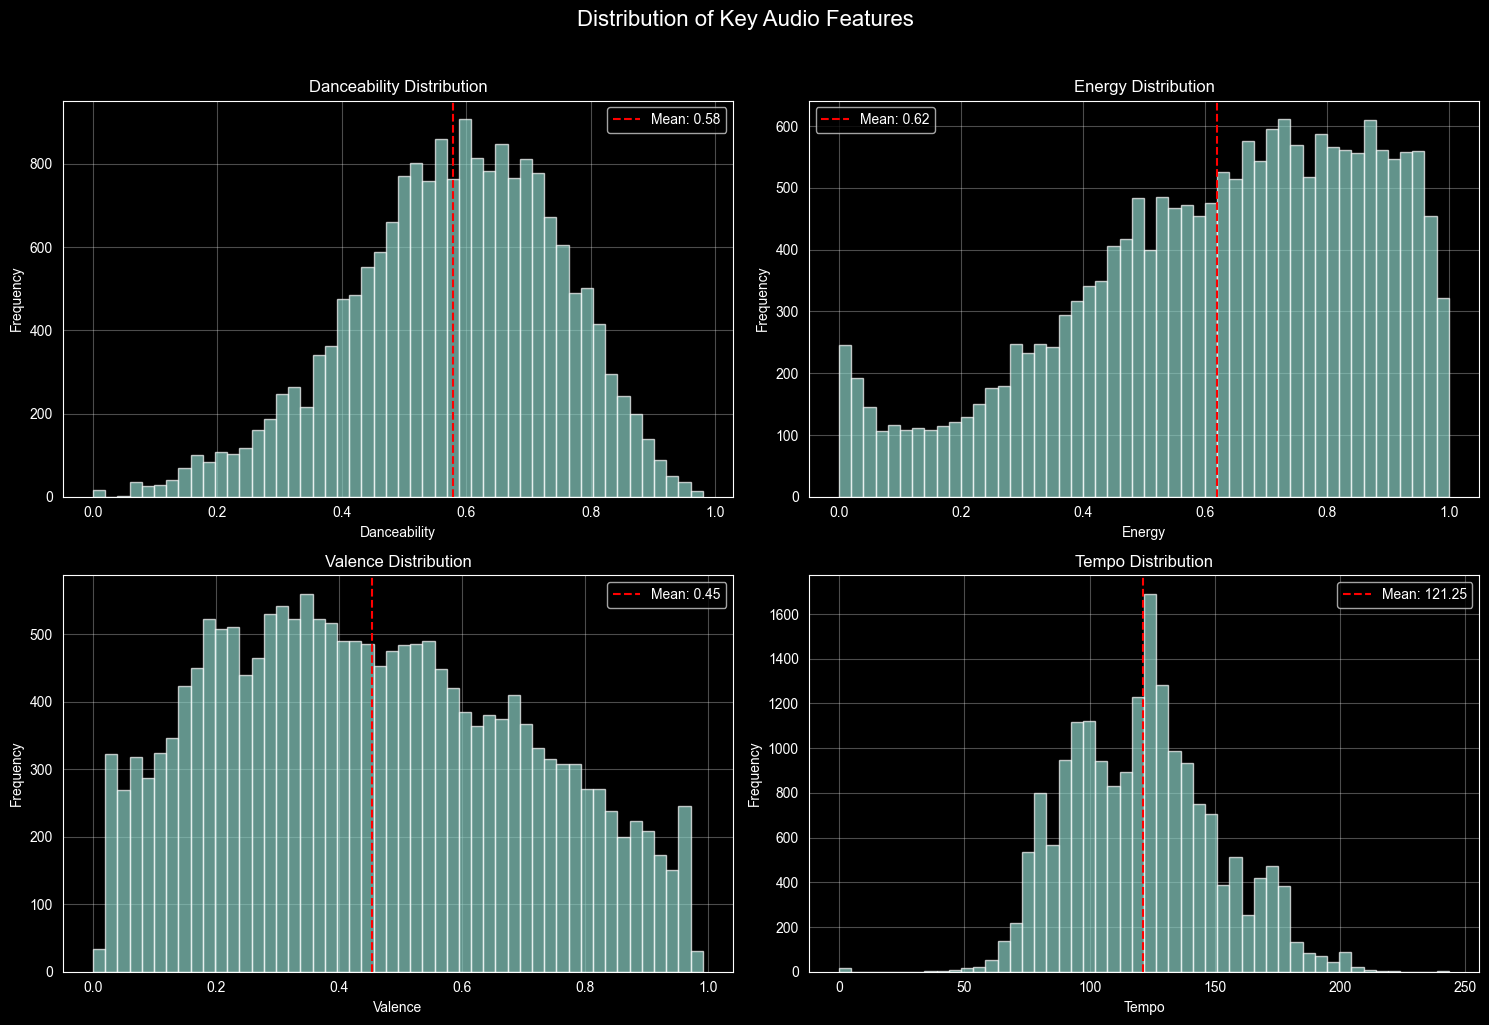

In [4]:
# Audio features to analyze
audio_features = ['danceability', 'energy', 'valence', 'tempo']

# Create subplot for feature distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Audio Features', fontsize=16, y=1.02)

for i, feature in enumerate(audio_features):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Histogram
    spotify[feature].hist(bins=50, alpha=0.7, ax=ax)
    ax.axvline(spotify[feature].mean(), color='red', linestyle='--', 
               label=f'Mean: {spotify[feature].mean():.2f}')
    ax.set_title(f'{feature.capitalize()} Distribution')
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 What Makes a Song Popular?

Let's investigate the relationship between audio features and song popularity.

In [5]:
# Create popularity categories for easier analysis
spotify_extended = add_columns(spotify, 
    is_highly_popular="popularity >= 80",
    is_fast_tempo="tempo >= 120"
)

# Create popularity categories using numpy.where for multiple conditions
spotify_extended['popularity_category'] = np.where(
    spotify_extended['popularity'] >= 75, 'High',
    np.where(spotify_extended['popularity'] >= 50, 'Medium', 'Low')
)

spotify_extended['tempo_category'] = np.where(
    spotify_extended['tempo'] >= 120, 'Fast', 'Slow'
)

print("Popularity categories:")
print(spotify_extended['popularity_category'].value_counts())

# Analyze average audio features by popularity category
popularity_analysis = spotify_extended.groupby('popularity_category')[audio_features].mean()
print("\nAverage audio features by popularity category:")
print(popularity_analysis.round(3))

Popularity categories:
popularity_category
Medium    17388
High       1291
Name: count, dtype: int64

Average audio features by popularity category:
                     danceability  energy  valence    tempo
popularity_category                                        
High                        0.640   0.676    0.523  120.324
Medium                      0.574   0.616    0.448  121.314


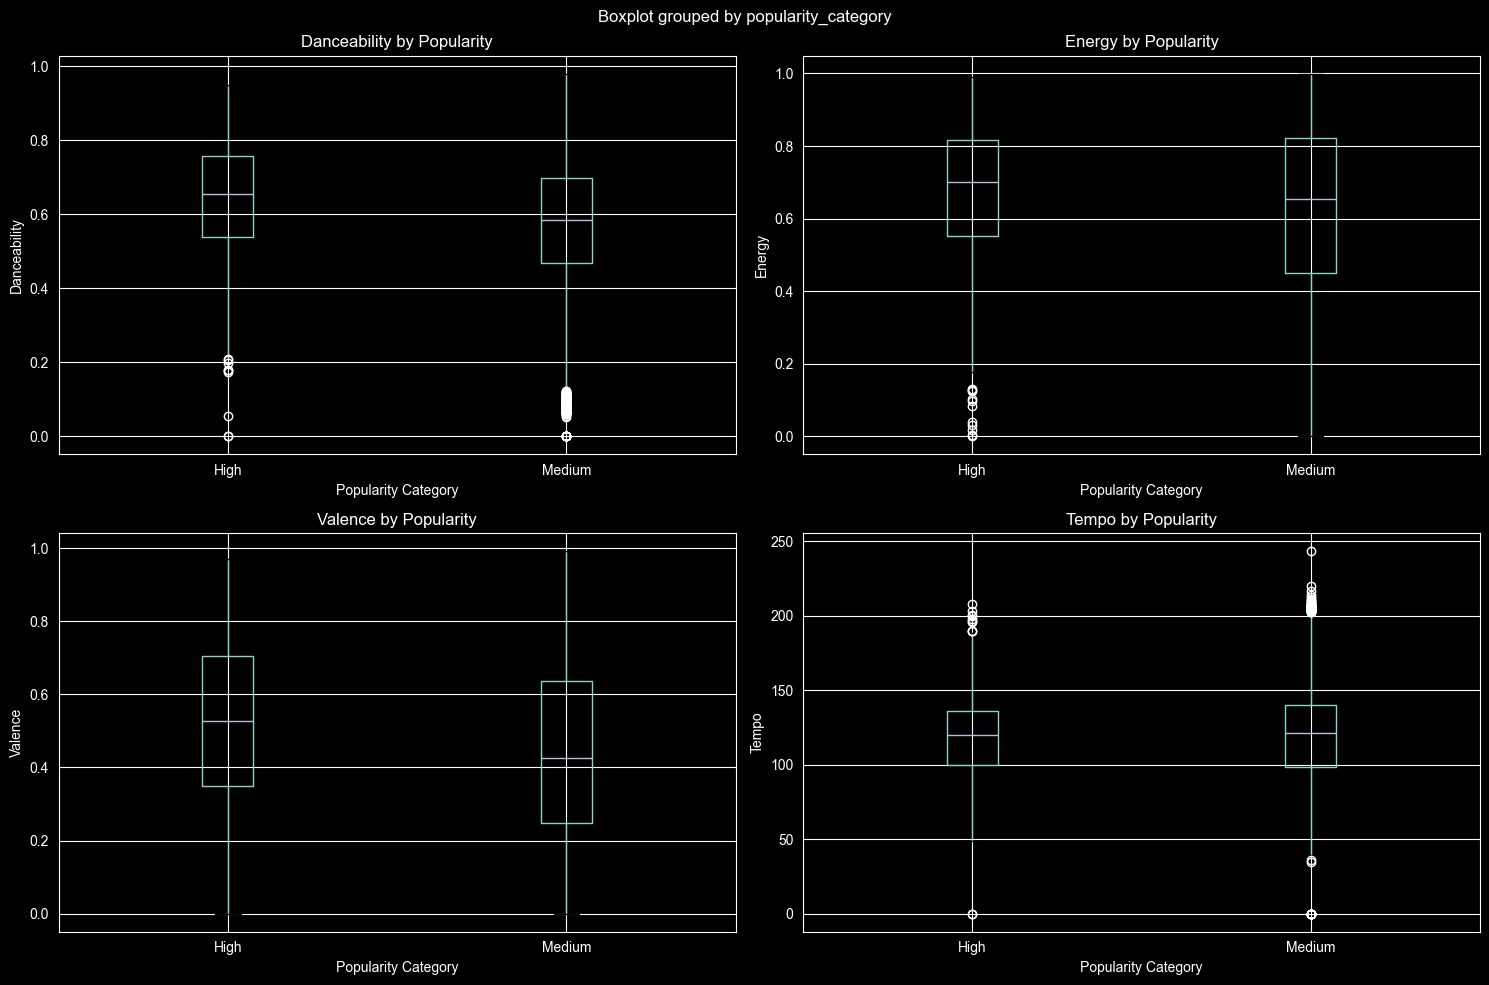

In [6]:
# Visualize audio features by popularity category
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Audio Features by Popularity Category', fontsize=16, y=1.02)

for i, feature in enumerate(audio_features):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Box plot by popularity category
    spotify_extended.boxplot(column=feature, by='popularity_category', ax=ax)
    ax.set_title(f'{feature.capitalize()} by Popularity')
    ax.set_xlabel('Popularity Category')
    ax.set_ylabel(feature.capitalize())

plt.tight_layout()
plt.show()

Correlation with Popularity:
popularity      1.000
valence         0.147
danceability    0.127
energy          0.083
tempo          -0.023
Name: popularity, dtype: float64


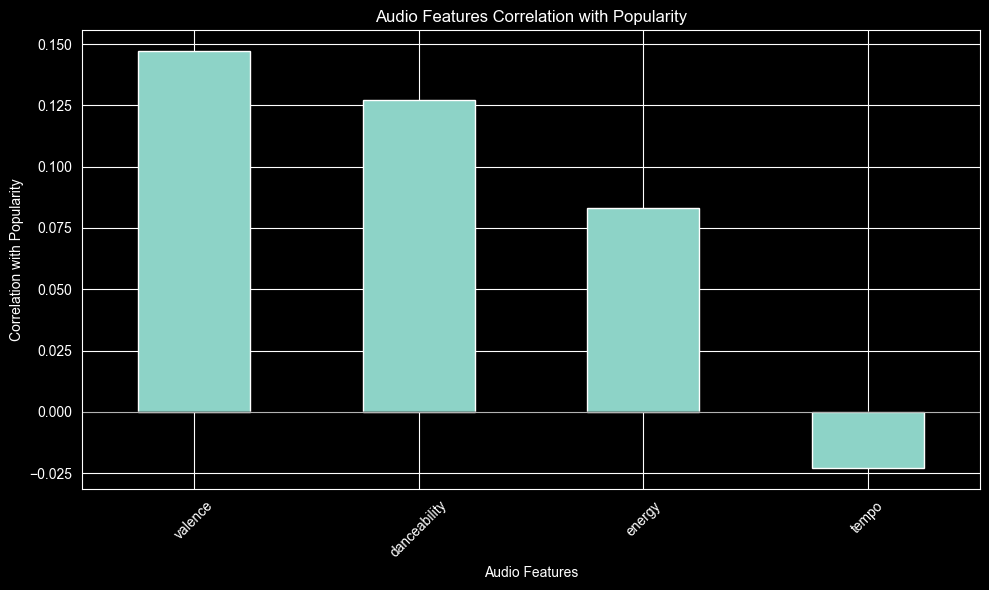

In [7]:
# Correlation analysis between popularity and audio features
correlation_data = spotify[['popularity'] + audio_features].corr()['popularity'].sort_values(ascending=False)
print("Correlation with Popularity:")
print(correlation_data.round(3))

# Visualize correlations
plt.figure(figsize=(10, 6))
correlation_data[1:].plot(kind='bar')
plt.title('Audio Features Correlation with Popularity')
plt.xlabel('Audio Features')
plt.ylabel('Correlation with Popularity')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

## 🎶 Genre Audio Signatures

Different music genres should have distinct "audio signatures". Let's explore how genres differ in their audio characteristics.

In [8]:
# Focus on top genres for clearer visualization
top_genres = spotify['track_genre'].value_counts().head(8).index.tolist()
spotify_top_genres = filter_data(spotify, track_genre=top_genres)

print(f"Analyzing {len(top_genres)} most common genres: {top_genres}")

# Average audio features by genre
genre_features = summarize_by_group(spotify_top_genres, 'track_genre', audio_features, 'mean')
print("\nAverage audio features by genre:")
print(genre_features.round(3))

Analyzing 8 most common genres: ['pop-film', 'chill', 'k-pop', 'hip-hop', 'deep-house', 'ambient', 'anime', 'british']

Average audio features by genre:
             danceability  energy  valence    tempo
track_genre                                        
deep-house          0.706   0.745    0.447  120.259
hip-hop             0.702   0.700    0.550  117.794
chill               0.671   0.434    0.419  115.161
k-pop               0.646   0.702    0.559  120.201
pop-film            0.596   0.601    0.527  117.161
anime               0.530   0.692    0.455  125.465
british             0.529   0.525    0.490  120.612
ambient             0.370   0.227    0.174  112.345


Average popularity by genre:
             popularity
track_genre            
hip-hop           64.72
k-pop             64.46
pop-film          61.30
british           60.95
chill             59.42
anime             57.40
deep-house        56.74
ambient           56.40


<Figure size 1200x600 with 0 Axes>

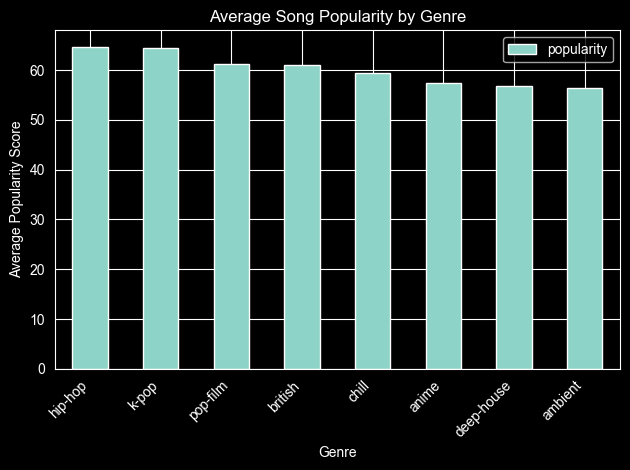

In [9]:
# Genre popularity analysis
genre_popularity = summarize_by_group(spotify_top_genres, 'track_genre', 'popularity', 'mean').sort_values('popularity', ascending=False)
print("Average popularity by genre:")
print(genre_popularity.round(2))

# Visualize genre popularity
plt.figure(figsize=(12, 6))
genre_popularity.plot(kind='bar')
plt.title('Average Song Popularity by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Popularity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🔗 Feature Relationships

Let's explore how different audio features relate to each other.

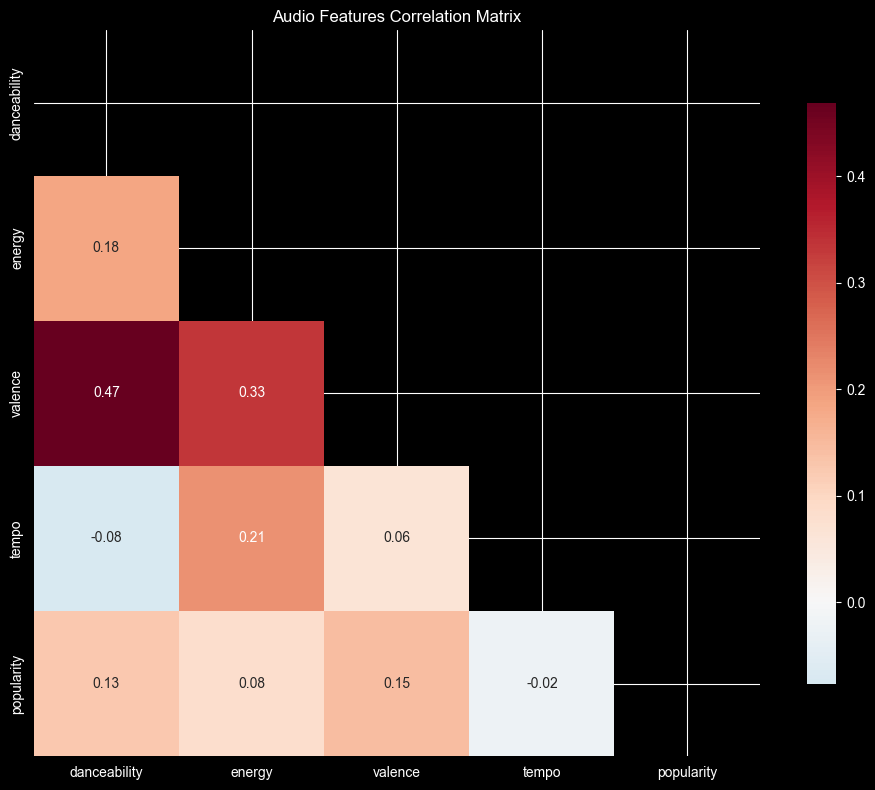

Key correlations:
Energy vs Valence: 0.334
Danceability vs Energy: 0.184
Tempo vs Danceability: -0.077


In [10]:
# Correlation matrix of audio features
feature_correlation = spotify[audio_features + ['popularity']].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(feature_correlation, dtype=bool))  # Hide upper triangle
sns.heatmap(feature_correlation, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Audio Features Correlation Matrix')
plt.tight_layout()
plt.show()

print("Key correlations:")
print(f"Energy vs Valence: {feature_correlation.loc['energy', 'valence']:.3f}")
print(f"Danceability vs Energy: {feature_correlation.loc['danceability', 'energy']:.3f}")
print(f"Tempo vs Danceability: {feature_correlation.loc['tempo', 'danceability']:.3f}")

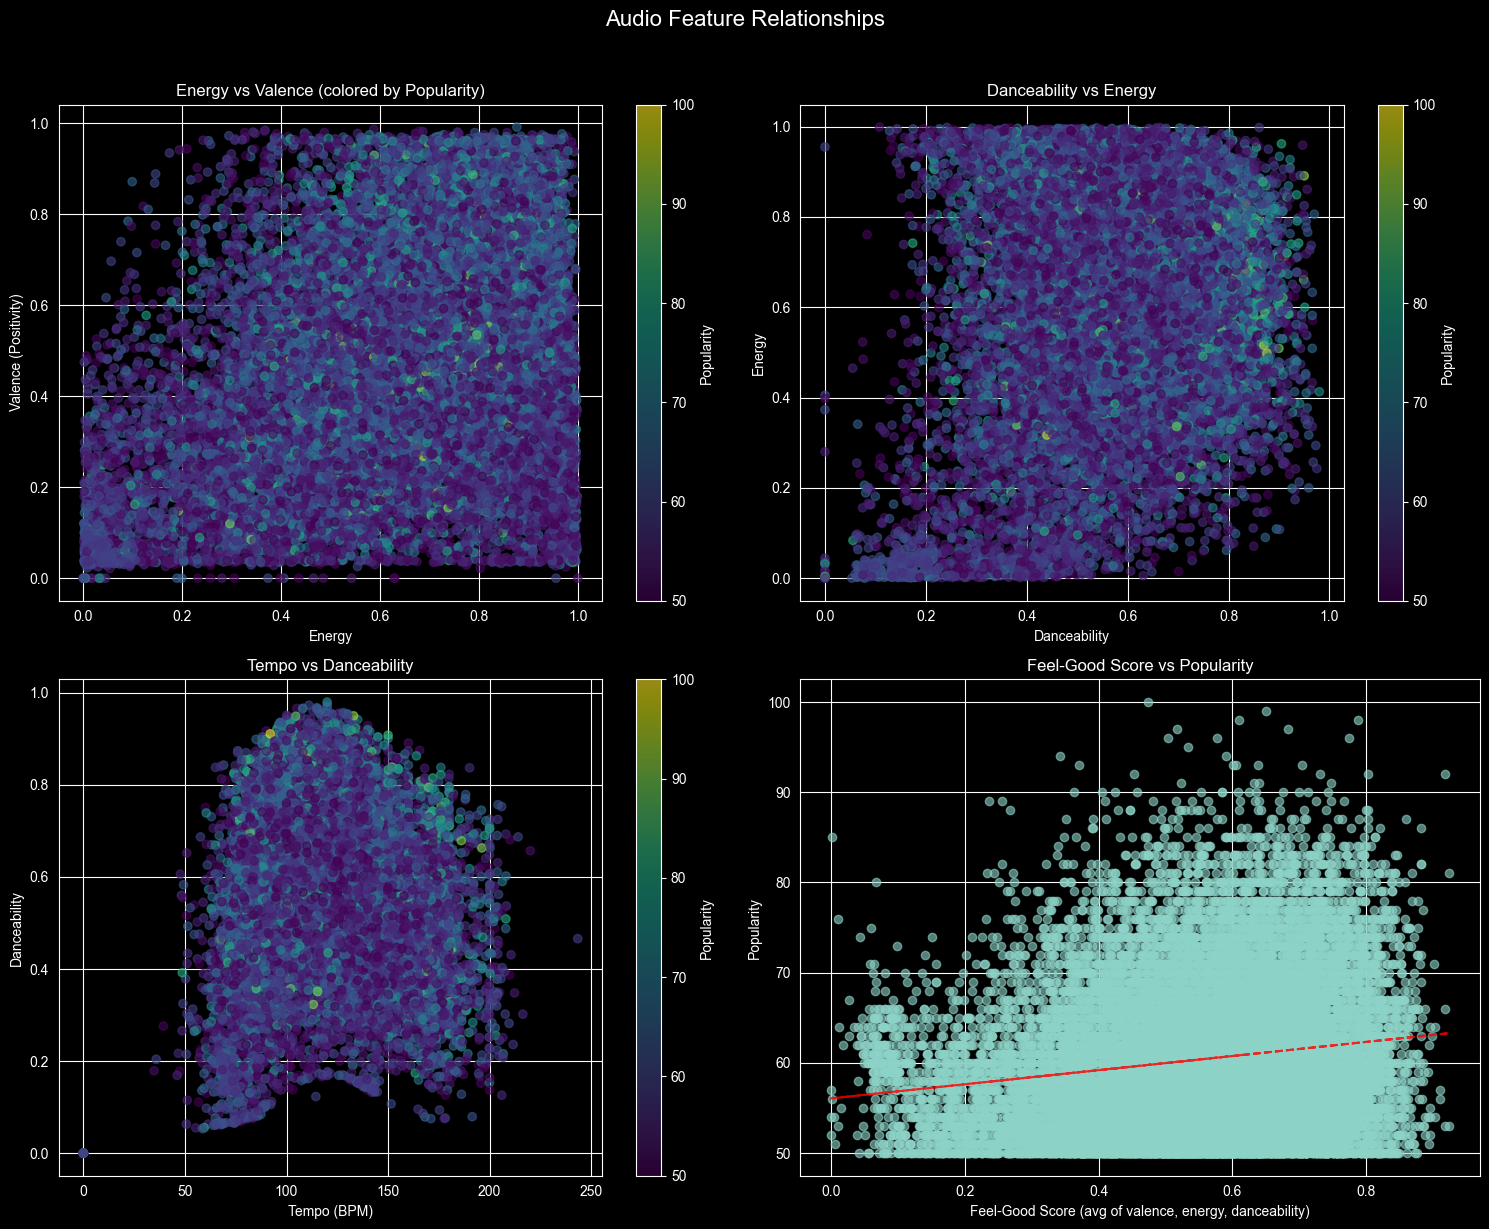

Correlation between Feel-Good Score and Popularity: 0.158


In [11]:
# Scatter plots of interesting feature relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Audio Feature Relationships', fontsize=16, y=1.02)

# Energy vs Valence (colored by popularity)
scatter1 = axes[0,0].scatter(spotify['energy'], spotify['valence'], 
                           c=spotify['popularity'], cmap='viridis', alpha=0.6)
axes[0,0].set_xlabel('Energy')
axes[0,0].set_ylabel('Valence (Positivity)')
axes[0,0].set_title('Energy vs Valence (colored by Popularity)')
plt.colorbar(scatter1, ax=axes[0,0], label='Popularity')

# Danceability vs Energy
scatter2 = axes[0,1].scatter(spotify['danceability'], spotify['energy'], 
                           c=spotify['popularity'], cmap='viridis', alpha=0.6)
axes[0,1].set_xlabel('Danceability')
axes[0,1].set_ylabel('Energy')
axes[0,1].set_title('Danceability vs Energy')
plt.colorbar(scatter2, ax=axes[0,1], label='Popularity')

# Tempo vs Danceability
scatter3 = axes[1,0].scatter(spotify['tempo'], spotify['danceability'], 
                           c=spotify['popularity'], cmap='viridis', alpha=0.6)
axes[1,0].set_xlabel('Tempo (BPM)')
axes[1,0].set_ylabel('Danceability')
axes[1,0].set_title('Tempo vs Danceability')
plt.colorbar(scatter3, ax=axes[1,0], label='Popularity')

# Popularity vs composite "feel-good" score
spotify['feel_good_score'] = (spotify['valence'] + spotify['energy'] + spotify['danceability']) / 3
scatter4 = axes[1,1].scatter(spotify['feel_good_score'], spotify['popularity'], alpha=0.6)
axes[1,1].set_xlabel('Feel-Good Score (avg of valence, energy, danceability)')
axes[1,1].set_ylabel('Popularity')
axes[1,1].set_title('Feel-Good Score vs Popularity')

# Add trend line
z = np.polyfit(spotify['feel_good_score'], spotify['popularity'], 1)
p = np.poly1d(z)
axes[1,1].plot(spotify['feel_good_score'], p(spotify['feel_good_score']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

print(f"Correlation between Feel-Good Score and Popularity: {spotify['feel_good_score'].corr(spotify['popularity']):.3f}")

## 🏆 Top Songs Analysis

Let's examine the most popular songs and see what characteristics they share.

In [12]:
# Get top 20 most popular songs
top_songs = get_top_n(spotify, 'popularity', n=20)[['track_name', 'artists', 'popularity', 'track_genre'] + audio_features]
print("Top 20 Most Popular Songs:")
print(top_songs.round(2))

Top 20 Most Popular Songs:
                                    track_name                     artists  \
4140                 Unholy (feat. Kim Petras)        Sam Smith;Kim Petras   
10122    Quevedo: Bzrp Music Sessions, Vol. 52            Bizarrap;Quevedo   
4146                           I'm Good (Blue)     David Guetta;Bebe Rexha   
12072                               La Bachata               Manuel Turizo   
12075                         Tití Me Preguntó                   Bad Bunny   
12074                          Me Porto Bonito  Bad Bunny;Chencho Corleone   
13571                          I Ain't Worried                 OneRepublic   
4139                       Under The Influence                 Chris Brown   
12084                                   Efecto                   Bad Bunny   
12077                            Ojitos Lindos     Bad Bunny;Bomba Estéreo   
14697                            Glimpse of Us                        Joji   
12088                              Mo

🎵 EXTREME VALUES IN AUDIO FEATURES

Most Energetic:
                 track_name        artists  energy track_genre  popularity
Meeresrauschen zum Schlafen Meeresrauschen   0.999       sleep          52
              Voodoo People    The Prodigy   0.998   breakbeat          56
                      Bleed      Meshuggah   0.998 death-metal          60
----------------------------------------------------------------------

Least Energetic:
                                                               track_name                         artists  energy track_genre  popularity
                                              Box Fan Long Loop For Sleep                      Fan Sounds 0.00002       sleep          54
                                                  Noise for Restless Kids Water Sound Natural White Noise 0.00002       sleep          52
Constant Broad Spectrum Noise Loop to Drown Out Sounds & Loud City Noises          White Noise Baby Sleep 0.00002       sleep          62
-------

C:\Users\stein\AppData\Local\Temp\ipykernel_35708\3784469736.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  extremes['Slowest Tempo'] = spotify.nsmallest(3, 'tempo')[spotify['tempo'] > 0][['track_name', 'artists', 'tempo', 'track_genre', 'popularity']]


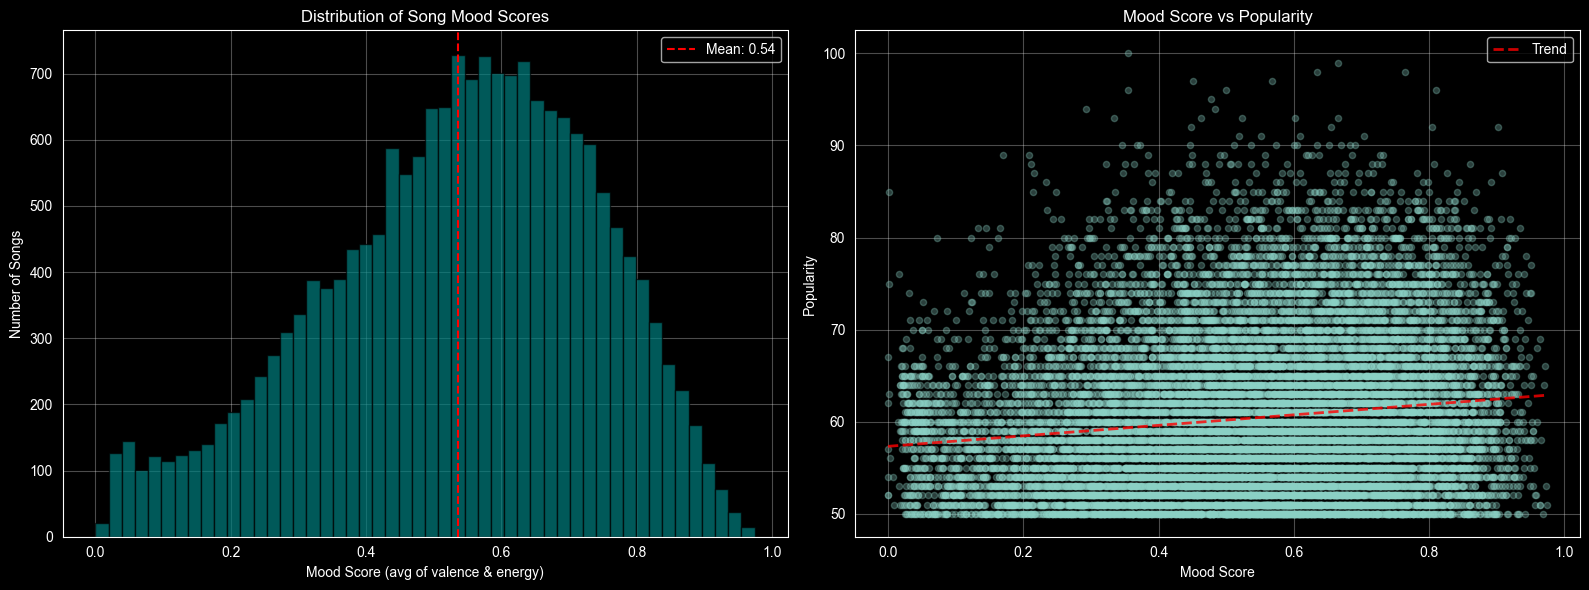


Correlation between Mood Score and Popularity: 0.141


In [13]:
# Find songs with extreme values
extremes = {}

# Most/least energetic
extremes['Most Energetic'] = spotify.nlargest(3, 'energy')[['track_name', 'artists', 'energy', 'track_genre', 'popularity']]
extremes['Least Energetic'] = spotify.nsmallest(3, 'energy')[['track_name', 'artists', 'energy', 'track_genre', 'popularity']]

# Most/least danceable
extremes['Most Danceable'] = spotify.nlargest(3, 'danceability')[['track_name', 'artists', 'danceability', 'track_genre', 'popularity']]
extremes['Least Danceable'] = spotify.nsmallest(3, 'danceability')[['track_name', 'artists', 'danceability', 'track_genre', 'popularity']]

# Most/least valence (happy/sad)
extremes['Most Happy'] = spotify.nlargest(3, 'valence')[['track_name', 'artists', 'valence', 'track_genre', 'popularity']]
extremes['Most Sad'] = spotify.nsmallest(3, 'valence')[['track_name', 'artists', 'valence', 'track_genre', 'popularity']]

# Fastest/slowest tempo
extremes['Fastest Tempo'] = spotify.nlargest(3, 'tempo')[['track_name', 'artists', 'tempo', 'track_genre', 'popularity']]
extremes['Slowest Tempo'] = spotify.nsmallest(3, 'tempo')[spotify['tempo'] > 0][['track_name', 'artists', 'tempo', 'track_genre', 'popularity']]

print("🎵 EXTREME VALUES IN AUDIO FEATURES\n" + "="*70)
for category, songs in extremes.items():
    print(f"\n{category}:")
    print(songs.to_string(index=False))
    print("-"*70)

# Analyze the "feel-good" vs "melancholic" songs
spotify['mood_score'] = (spotify['valence'] + spotify['energy']) / 2  # High = feel-good, Low = melancholic

feel_good_songs = spotify.nlargest(10, 'mood_score')[['track_name', 'artists', 'valence', 'energy', 'mood_score', 'popularity']]
melancholic_songs = spotify.nsmallest(10, 'mood_score')[['track_name', 'artists', 'valence', 'energy', 'mood_score', 'popularity']]

print("\n\n🌟 TOP 10 'FEEL-GOOD' SONGS (High Energy + Valence)")
print(feel_good_songs.round(3).to_string(index=False))

print("\n\n🌧️ TOP 10 'MELANCHOLIC' SONGS (Low Energy + Valence)")
print(melancholic_songs.round(3).to_string(index=False))

# Distribution of mood scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mood score distribution
axes[0].hist(spotify['mood_score'], bins=50, alpha=0.7, color='teal', edgecolor='black')
axes[0].axvline(spotify['mood_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {spotify["mood_score"].mean():.2f}')
axes[0].set_xlabel('Mood Score (avg of valence & energy)')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Distribution of Song Mood Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mood score vs popularity
axes[1].scatter(spotify['mood_score'], spotify['popularity'], alpha=0.3, s=20)
axes[1].set_xlabel('Mood Score')
axes[1].set_ylabel('Popularity')
axes[1].set_title('Mood Score vs Popularity')

# Add trend line
z = np.polyfit(spotify['mood_score'], spotify['popularity'], 1)
p = np.poly1d(z)
x_trend = np.linspace(spotify['mood_score'].min(), spotify['mood_score'].max(), 100)
axes[1].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation between Mood Score and Popularity: {spotify['mood_score'].corr(spotify['popularity']):.3f}")

## 💎 Extreme Values & Outliers

Let's explore songs with extreme values in different audio features.

Top 15 Genres by Average Popularity:
             avg_popularity  median_popularity  max_popularity  song_count
track_genre                                                               
dance                 76.98               78.0             100         226
rock                  75.27               77.0              90          52
latino                74.91               76.0              90         170
reggaeton             71.58               74.0              81          19
pop                   71.02               68.0              94         206
latin                 70.59               70.0              98          81
alternative           69.52               69.0              87         115
salsa                 69.00               70.0              77          11
electro               68.70               69.0              86         235
indie-pop             68.37               69.0              86         236
alt-rock              68.22               69.0              93 

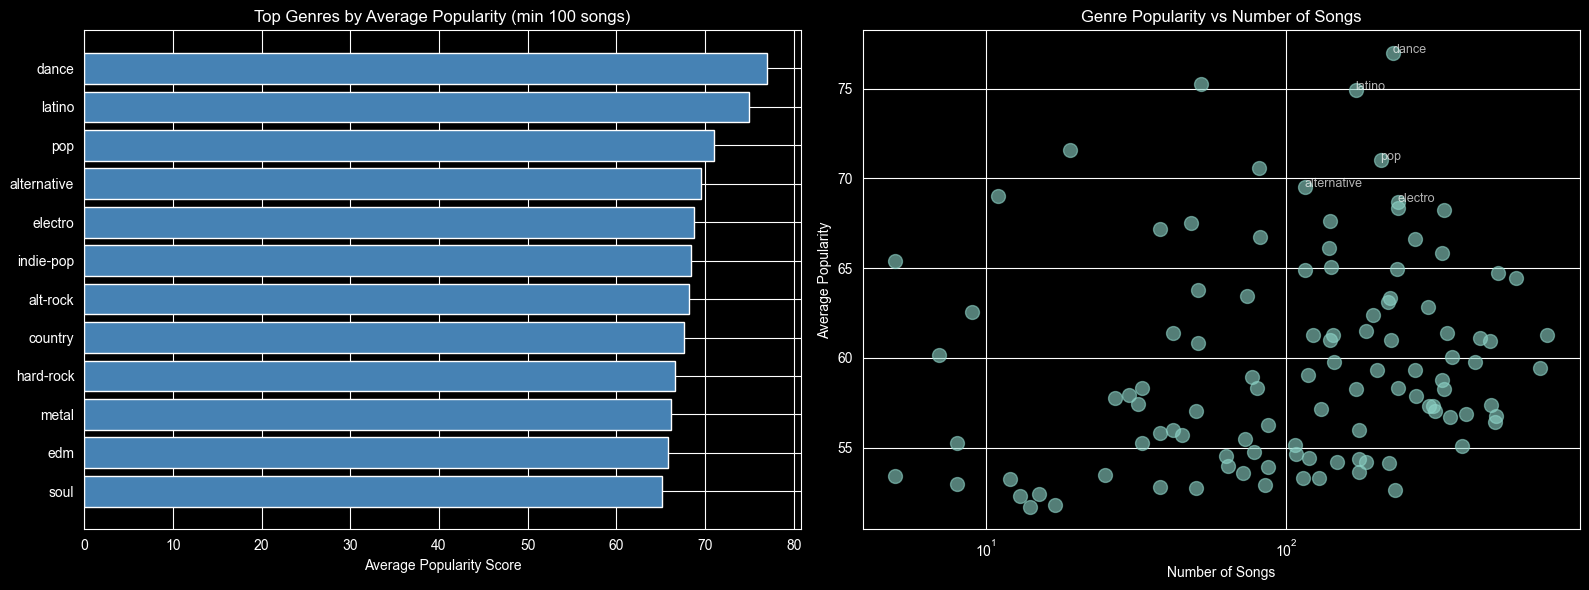


Audio characteristics of most popular genres:
             danceability  energy  valence    tempo  explicit_%
track_genre                                                    
latino              0.759   0.726    0.603  121.368      34.118
alternative         0.609   0.733    0.473  119.523      32.174
electro             0.654   0.576    0.440  121.459      25.106
dance               0.680   0.685    0.522  119.191      21.681
indie-pop           0.609   0.559    0.473  123.643      18.220
alt-rock            0.527   0.732    0.450  121.547       8.060
pop                 0.600   0.596    0.480  120.205       7.282
country             0.559   0.552    0.517  121.976       2.857


In [14]:
# Analyze genres with highest average popularity
genre_pop_stats = spotify.groupby('track_genre').agg({
    'popularity': ['mean', 'median', 'max', 'count']
}).round(2)
genre_pop_stats.columns = ['avg_popularity', 'median_popularity', 'max_popularity', 'song_count']
genre_pop_stats = genre_pop_stats.sort_values('avg_popularity', ascending=False)

print("Top 15 Genres by Average Popularity:")
print(genre_pop_stats.head(15))

# Filter genres with at least 100 songs for statistical relevance
popular_genres = genre_pop_stats[genre_pop_stats['song_count'] >= 100].head(12)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of average popularity
axes[0].barh(range(len(popular_genres)), popular_genres['avg_popularity'], color='steelblue')
axes[0].set_yticks(range(len(popular_genres)))
axes[0].set_yticklabels(popular_genres.index)
axes[0].set_xlabel('Average Popularity Score')
axes[0].set_title('Top Genres by Average Popularity (min 100 songs)')
axes[0].invert_yaxis()

# Scatter: Song count vs Average popularity
axes[1].scatter(genre_pop_stats['song_count'], genre_pop_stats['avg_popularity'], 
                alpha=0.6, s=100)
axes[1].set_xlabel('Number of Songs')
axes[1].set_ylabel('Average Popularity')
axes[1].set_title('Genre Popularity vs Number of Songs')
axes[1].set_xscale('log')

# Annotate some interesting genres
for idx in popular_genres.head(5).index:
    axes[1].annotate(idx, 
                     (genre_pop_stats.loc[idx, 'song_count'], 
                      genre_pop_stats.loc[idx, 'avg_popularity']),
                     fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Get characteristics of most popular genres
top_genre_names = popular_genres.head(8).index.tolist()
top_genre_data = filter_data(spotify, track_genre=top_genre_names)

genre_characteristics = top_genre_data.groupby('track_genre')[
    ['danceability', 'energy', 'valence', 'tempo', 'explicit']
].agg({
    'danceability': 'mean',
    'energy': 'mean',
    'valence': 'mean',
    'tempo': 'mean',
    'explicit': lambda x: (x.sum() / len(x) * 100)  # Percentage explicit
}).round(3)
genre_characteristics.columns = ['danceability', 'energy', 'valence', 'tempo', 'explicit_%']

print("\nAudio characteristics of most popular genres:")
print(genre_characteristics.sort_values('explicit_%', ascending=False))